# Notebook 02: Regression Model

**Student Name:** Denz'l Chapman

**Dataset:** Industry Marketcap Data

**Target Variable:** MarketCap

**Checkpoint 3 Due:** Feb 15

---

## Rules & Integrity

1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, GitHub Copilot, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.

2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, share approaches, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own work**.

3. **Use Your Resources**: You are free to use Google, StackOverflow, Pandas/Scikit-learn documentation, and your class notes.

4. **Comment Your Code**: Include comments explaining *why* you're doing what you're doing. I want to see your thought process.

5. **Resubmission**: You may submit this assignment multiple times for feedback before the checkpoint deadline.

---

## Important: Written Reflections

Throughout this notebook, you'll be asked to interpret results, justify decisions, and explain your reasoning. **These written reflections are a critical part of your grade.**

Good data scientists don't just run code—they communicate their findings clearly. Take time to write thoughtful, complete responses to all reflection prompts. This demonstrates your understanding and prepares you for real-world stakeholder communication.

---

## Setup

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Sklearn - models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Sklearn - evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model saving
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Load Processed Data

In [2]:
# Load cleaned data from previous notebook
df = pd.read_csv('../data/processed/cleaned_data.csv')

print(f"Data shape: {df.shape}")
df.head()

Data shape: (1490, 25)


,marketcap,revenue,earnings,operating-margin,total-assets,total-liabilities,total-debt,net-assets,pe-ratio,ps-ratio,...,Industry_Oil&Gas,Industry_Pharmaceuticals,Industry_Real Estate,Industry_Retail,Industry_Technology,Country_India,Country_Japan,Country_Other,Country_UK,Country_USA
0,7.584265,6.355726,3.731220,-0.0115,6.270705,5.789868,4.917130,5.312565,96.50,3.4200,...,0,0,0,0,1,0,0,0,0,1
1,4.185860,5.294912,1.968510,0.0255,4.862908,4.309993,3.457263,4.024458,16.10,0.3255,...,0,0,0,0,1,0,0,1,0,0
2,3.772761,5.033570,1.776646,0.0255,4.467975,3.824721,2.374906,3.745968,13.70,0.2839,...,0,0,0,0,1,0,0,0,0,0
3,5.144117,4.140751,2.271094,0.0308,4.914418,4.732860,4.109726,3.161670,24.40,2.7600,...,0,0,0,0,1,0,0,0,0,1
4,3.114848,4.104955,1.427916,0.0487,4.162159,3.505257,2.509599,3.463233,7.18,0.3597,...,0,0,0,0,1,0,1,0,0,0


In [3]:
# Define your target variable
TARGET = 'marketcap'  # <-- UPDATE THIS!

print(f"Target: {TARGET}")
print(f"\nTarget statistics:")
print(df[TARGET].describe())

# Store target range for later interpretation
target_range = df[TARGET].max() - df[TARGET].min()
target_std = df[TARGET].std()
print(f"\nTarget range: {target_range:,.2f}")
print(f"Target std: {target_std:,.2f}")

Target: marketcap

Target statistics:
count    1490.000000
mean        2.124606
std         1.400941
min         0.000070
25%         1.025134
50%         1.916185
75%         2.987321
max         8.064636
Name: marketcap, dtype: float64

Target range: 8.06
Target std: 1.40


## Section 2: Prepare Features and Target

In [4]:
# Separate features (X) and target (y)
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nAll features ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (1490, 24)
Target shape: (1490,)

All features (24):
['revenue', 'earnings', 'operating-margin', 'total-assets', 'total-liabilities', 'total-debt', 'net-assets', 'pe-ratio', 'ps-ratio', 'return-on-assets', 'return-on-equity', 'debt-to-equity', 'Industry_Food', 'Industry_Insurance', 'Industry_Oil&Gas', 'Industry_Pharmaceuticals', 'Industry_Real Estate', 'Industry_Retail', 'Industry_Technology', 'Country_India', 'Country_Japan', 'Country_Other', 'Country_UK', 'Country_USA']


In [5]:
# Creating seperarte features to test the models with & without PE/PS Ratios. 
# I want to see the difference in model performance when exposed to the features PE/PS Ratio

X_without_features = df.drop(columns = [TARGET, 'pe-ratio', 'ps-ratio'])

print(f"Features shape: {X_without_features.shape}")
print(X_without_features.columns.tolist())

Features shape: (1490, 22)
['revenue', 'earnings', 'operating-margin', 'total-assets', 'total-liabilities', 'total-debt', 'net-assets', 'return-on-assets', 'return-on-equity', 'debt-to-equity', 'Industry_Food', 'Industry_Insurance', 'Industry_Oil&Gas', 'Industry_Pharmaceuticals', 'Industry_Real Estate', 'Industry_Retail', 'Industry_Technology', 'Country_India', 'Country_Japan', 'Country_Other', 'Country_UK', 'Country_USA']


In [6]:
# Check for any non-numeric columns that need to be handled
non_numeric = X.select_dtypes(include=['object', 'category']).columns.tolist()
if non_numeric:
    print(f"Warning: Non-numeric columns found: {non_numeric}")
    print("You need to encode these or go back to Notebook 01!")
else:
    print("All features are numeric. Ready to proceed!")

All features are numeric. Ready to proceed!


## Section 3: Train-Test Split

Split your data into training and test sets. The training set is used to train the model, and the test set is used to evaluate how well it generalizes to unseen data.

In [7]:
# TODO: Split your data into training and test sets
# 
# Requirements:
# - Use an 80/20 split (test_size=0.2)
# - Set random_state=42 for reproducibility
# - Store results in: X_train, X_test, y_train, y_test
#
# Hint: Use train_test_split(X, y, ...)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f"Features Training: {len(X_train)} Samples (80%)")  # Lets check/print out the Size of the testing and training sets
print(f"Features Testing: {len(X_test)} Samples(20%)")
print(f"Target Training: {len(y_train)} Samples(80%)")
print(f"Target Testing: {len(y_test)} Samples(20%)")

Features Training: 1192 Samples (80%)
Features Testing: 298 Samples(20%)
Target Training: 1192 Samples(80%)
Target Testing: 298 Samples(20%)


In [8]:
# Seperate Train_Test_Split for our non PE/PS features
# Can keep the same y because its just the TARGET

X_train_without, X_test_without, y_train_without, y_test_without = train_test_split(X_without_features, y, test_size = 0.2, random_state = 42)

print(f"Features Training: {len(X_train_without)} Samples (80%)")  
print(f"Features Testing: {len(X_test_without)} Samples(20%)")

Features Training: 1192 Samples (80%)
Features Testing: 298 Samples(20%)


In [9]:
# Verify your split (run this cell to check)
print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

Training set: 1,192 samples (80%)
Test set: 298 samples (20%)


## Section 4: Feature Scaling

Many ML algorithms perform better when features are on similar scales. StandardScaler transforms features to have mean=0 and std=1.

**Important:** Fit the scaler on training data only, then transform both train and test. This prevents data leakage.

In [10]:
# TODO: Scale your features using StandardScaler
#
# Steps:
# 1. Create a StandardScaler instance
# 2. Fit the scaler on X_train and transform X_train (use fit_transform)
# 3. Transform X_test using the same scaler (use transform only - NOT fit_transform!)
# 4. Store results in: X_train_scaled, X_test_scaled
#
# Why fit only on train? To prevent "data leakage" - test data should be truly unseen.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
# Scaling the Non PE/PS Ratio features

X_train_without_scaled = scaler.fit_transform(X_train_without)
X_test_without_scaled = scaler.transform(X_test_without)

In [12]:
# Convert back to DataFrame for easier viewing (optional but helpful)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Verify scaling worked
print("Features scaled successfully!")
print(f"\nScaled feature means (should be ~0): {X_train_scaled.mean().mean():.4f}")
print(f"Scaled feature stds (should be ~1): {X_train_scaled.std().mean():.4f}")

Features scaled successfully!

Scaled feature means (should be ~0): -0.0000
Scaled feature stds (should be ~1): 1.0004


## Section 5: Baseline Model

Start with a simple Linear Regression to establish a baseline performance. This gives us a reference point for improvement.

In [13]:
# This helper function evaluates any model - you'll use it throughout this notebook
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train model and return evaluation metrics."""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Train R2': r2_score(y_train, y_train_pred),
        'Test R2': r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred)
    }
    
    return results, model, y_test_pred

In [14]:
# TODO: Create and evaluate a baseline Linear Regression model
#
# Steps:
# 1. Create a LinearRegression() model instance
# 2. Use the evaluate_model() function to train and evaluate it
# 3. Store the results
#
# The evaluate_model function returns: (results_dict, trained_model, predictions)

# YOUR CODE HERE:
# baseline_model = ...
# baseline_results, baseline_trained, baseline_preds = evaluate_model(...)

baseline_model = LinearRegression()
baseline_results, baseline_trained, baseline_preds = evaluate_model(baseline_model, X_train_scaled, X_test_scaled, y_train, y_test, "Baseline Linear Regression")

In [15]:
# Display baseline results
print("=" * 50)
print("BASELINE MODEL: Linear Regression")
print("=" * 50)
print(f"Train R²: {baseline_results['Train R2']:.4f}")
print(f"Test R²:  {baseline_results['Test R2']:.4f}")
print(f"Test RMSE: {baseline_results['Test RMSE']:,.2f}")
print(f"Test MAE: {baseline_results['Test MAE']:,.2f}")

# Context for RMSE
print(f"\n--- RMSE in Context ---")
print(f"RMSE as % of target range: {baseline_results['Test RMSE']/target_range*100:.1f}%")
print(f"RMSE as % of target std: {baseline_results['Test RMSE']/target_std*100:.1f}%")

BASELINE MODEL: Linear Regression
Train R²: 0.8538
Test R²:  0.6553
Test RMSE: 0.81
Test MAE: 0.44

--- RMSE in Context ---
RMSE as % of target range: 10.0%
RMSE as % of target std: 57.8%


### Baseline Interpretation

*Analyze your baseline results:*

**Understanding your metrics:**
- **R² (0 to 1)**: How much variance in target is explained by features. 0.7+ is often considered good.
- **RMSE**: Average prediction error in the same units as your target. Lower is better.
- **RMSE as % of range**: Helps you understand if errors are big or small relative to your data.

**Questions to answer:**
- What does your R² score tell you about how well features explain the target?
- Is there a big gap between train and test R²? (Gap > 0.1 could indicate overfitting)
- Is your RMSE reasonable? (e.g., if predicting house prices, is a $20K error acceptable?)

**Your interpretation:**

When evalutating the baseline LinearRegression model I got an R2 score of 0.8538 for the Training set and 0.6553 for the Testing set. This might be a good sign that the model is overfitting and simply memorizing the testing data. I find this interesting because in the training and test data I have both the PE & PS ratio which mathematically contain our Target variable marketcap. Technically this is a form of data leakage because when creating a model the model should not be influenced by any information containing the TARGET variable. As i continue through the notebook i am curious to see the difference in performance of the models when PE/PS Ratio are included features and when they are not. 

The RMSE as a percent of the target range seems reasonable at 10% but with an RMSE of 57% of Target std this means that the baseline model has a wide range in error whenn trying to predict our Target marketcap. Since my Target is marketcap in the Billions this would mean that the model would be about 57Billion off when trying to predict an actual of 100Billion. This shows that the model is good at giving an "Ballpark" eestimate but isnt good at being precise. 

## Section 6: Model Iteration

Try at least 2-3 different models to see if you can improve on the baseline.

In [16]:
# Store all results for comparison
all_results = [baseline_results]

# Dictionary to store trained models
trained_models = {
    'Linear Regression (Baseline)': baseline_trained
}

### Model 2: Ridge Regression

Ridge adds L2 regularization to prevent overfitting by penalizing large coefficients.

In [17]:
# TODO: Create and evaluate a Ridge Regression model
#
# Create a Ridge model with alpha=1.0
# Use evaluate_model() to train and evaluate
# Add results to all_results list
# Add trained model to trained_models dict

# YOUR CODE HERE:
ridge_model = Ridge(alpha=1.0)
ridge_results, ridge_trained, ridge_preds = evaluate_model(ridge_model, X_train_scaled, X_test_scaled, y_train, y_test, "Ridge Regression")
all_results.append(ridge_results)
trained_models['Ridge Regression'] = ridge_trained


# Print results
print(f"Ridge Regression - Test R²: {ridge_results['Test R2']:.4f}, Test RMSE: {ridge_results['Test RMSE']:,.2f}")

Ridge Regression - Test R²: 0.6545, Test RMSE: 0.81


In [18]:
# Creating Ridge Regression Model WITHOUT PE/PS Ratio

ridge_model_without = Ridge(alpha=1.0)
ridge_results_without, ridge_trained_without, ridge_preds_without = evaluate_model(ridge_model_without, X_train_without_scaled, X_test_without_scaled, y_train, y_test, "Ridge Regression Without")
all_results.append(ridge_results_without)
trained_models['Ridge Regression Without'] = ridge_trained_without


# Print results
print(f"Ridge Regression Without - Test R²: {ridge_results_without['Test R2']:.4f}, Test RMSE: {ridge_results_without['Test RMSE']:,.2f}")

Ridge Regression Without - Test R²: 0.8106, Test RMSE: 0.60


### Model 3: Lasso Regression

Lasso adds L1 regularization, which can zero out unimportant features (automatic feature selection).

In [19]:
# TODO: Create and evaluate a Lasso Regression model
#
# Create a Lasso model with alpha=0.1
# Use evaluate_model() to train and evaluate
# Add results to all_results and trained_models

# YOUR CODE HERE:
lasso_model = Lasso(alpha = 0.1)
lasso_results, lasso_trained, lasso_preds = evaluate_model(lasso_model, X_train_scaled, X_test_scaled, y_train, y_test, "Lasso Regression")
all_results.append(lasso_results)
trained_models['Lasso Regression'] = lasso_trained


# Print results
print(f"Lasso Regression - Test R²: {lasso_results['Test R2']:.4f}, Test RMSE: {lasso_results['Test RMSE']:,.2f}")

# Show which features Lasso kept (non-zero coefficients)
lasso_coefs = pd.Series(lasso_trained.coef_, index=X.columns)
kept_features = lasso_coefs[lasso_coefs != 0]
print(f"\nLasso kept {len(kept_features)} of {len(X.columns)} features")

Lasso Regression - Test R²: 0.6813, Test RMSE: 0.78

Lasso kept 8 of 24 features


In [20]:
# Creating Lasso Model WITHOUT PE/PS Ratio

lasso_model_without = Lasso(alpha = 0.1)
lasso_results_without, lasso_trained_without, lasso_preds_without = evaluate_model(lasso_model_without, X_train_without_scaled, X_test_without_scaled, y_train, y_test, "Lasso Regression Without")
all_results.append(lasso_results_without)
trained_models['Lasso Regression Without'] = lasso_trained_without


# Print results
print(f"Lasso Regression Without - Test R²: {lasso_results_without['Test R2']:.4f}, Test RMSE: {lasso_results_without['Test RMSE']:,.2f}")

# Show which features Lasso kept (non-zero coefficients)
lasso_coefs_without = pd.Series(lasso_trained_without.coef_, index=X_without_features.columns)
kept_features_without = lasso_coefs_without[lasso_coefs_without != 0]
print(f"\nLasso kept {len(kept_features_without)} of {len(X_without_features.columns)} features")

Lasso Regression Without - Test R²: 0.7441, Test RMSE: 0.70

Lasso kept 9 of 22 features


### Model 4: Decision Tree

In [21]:
# TODO: Create and evaluate a Decision Tree model
#
# Create a DecisionTreeRegressor with max_depth=10 and random_state=42
# Use evaluate_model() to train and evaluate
# Add results to all_results and trained_models

# YOUR CODE HERE:
dt_model = DecisionTreeRegressor(max_depth= 10, random_state= 42)
dt_results, dt_trained, dt_preds = evaluate_model(dt_model, X_train_scaled, X_test_scaled, y_train, y_test, "Decision Tree")
all_results.append(dt_results)
trained_models['Decision Tree'] = dt_trained

# Print results
print(f"Decision Tree - Test R²: {dt_results['Test R2']:.4f}, Test RMSE: {dt_results['Test RMSE']:,.2f}")

Decision Tree - Test R²: 0.8689, Test RMSE: 0.50


In [22]:
# Creating a Decision Tree WITHOUT PE/PS Ratio

dt_model_without = DecisionTreeRegressor(max_depth= 10, random_state= 42)
dt_results_without, dt_trained_without, dt_preds_without = evaluate_model(dt_model_without, X_train_without_scaled, X_test_without_scaled, y_train, y_test, "Decision Tree Without")
all_results.append(dt_results_without)
trained_models['Decision Tree Without'] = dt_trained_without

# Print results
print(f"Decision Tree Without - Test R²: {dt_results_without['Test R2']:.4f}, Test RMSE: {dt_results_without['Test RMSE']:,.2f}")

Decision Tree Without - Test R²: 0.6599, Test RMSE: 0.80


### Model 5: Random Forest

In [23]:
# TODO: Create and evaluate a Random Forest model
#
# Create a RandomForestRegressor with:
#   - n_estimators=100
#   - max_depth=10
#   - random_state=42
#   - n_jobs=-1 (use all CPU cores)
#
# Use evaluate_model() to train and evaluate
# Add results to all_results and trained_models

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_results, rf_trained, rf_preds = evaluate_model(rf_model, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest")
all_results.append(rf_results)
trained_models['Random Forest'] = rf_trained

# Print results
print(f"Random Forest - Test R²: {rf_results['Test R2']:.4f}, Test RMSE: {rf_results['Test RMSE']:,.2f}")

Random Forest - Test R²: 0.9362, Test RMSE: 0.35


In [24]:
# Creating a Random Forest WITHOUT PE/PS Ratio

rf_model_without = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_results_without, rf_trained_without, rf_preds_without = evaluate_model(rf_model_without, X_train_without_scaled, X_test_without_scaled, y_train, y_test, "Random Forest Without")
all_results.append(rf_results_without)
trained_models['Random Forest Without'] = rf_trained_without

# Print results
print(f"Random Forest Without - Test R²: {rf_results_without['Test R2']:.4f}, Test RMSE: {rf_results_without['Test RMSE']:,.2f}")

Random Forest Without - Test R²: 0.8104, Test RMSE: 0.60


### Add Your Own Model (Optional)

*Feel free to try additional models or tune hyperparameters!*

In [25]:
# YOUR ADDITIONAL MODEL HERE:
# Try GradientBoostingRegressor, different hyperparameters, etc.

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2, loss='squared_error', random_state=42)
gb_results, gb_trained, gb_preds = evaluate_model(gb_model, X_train_scaled, X_test_scaled, y_train, y_test, "Gradient Boosting")
all_results.append(gb_results)
trained_models['Gradient Boosting'] = gb_trained

print(f"Gradient Boosting Results - Test R2: {gb_results['Test R2']:.4f}, Test RMSE: {gb_results['Test RMSE']:,.2f}")


Gradient Boosting Results - Test R2: 0.9598, Test RMSE: 0.28


In [26]:
# Creating a GradientBost Model WITHOUT PE/PS Ratio

gb_model_without = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2, loss='squared_error', random_state=42)
gb_results_without, gb_trained_without, gb_preds_without = evaluate_model(gb_model_without, X_train_without_scaled, X_test_without_scaled, y_train, y_test, "Gradient Boosting Without")
all_results.append(gb_results)
trained_models['Gradient Boosting Without'] = gb_trained_without

print(f"Gradient Boosting Without Results - Test R2: {gb_results_without['Test R2']:.4f}, Test RMSE: {gb_results_without['Test RMSE']:,.2f}")

Gradient Boosting Without Results - Test R2: 0.8248, Test RMSE: 0.58


## Section 7: Cross-Validation (More Robust Evaluation)

Cross-validation gives us a more reliable estimate of model performance by testing on multiple different train/test splits.

In [27]:
# Perform 5-fold cross-validation on top models
print("5-Fold Cross-Validation Results:")
print("=" * 50)

cv_results = []

models_to_cv = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2, loss='squared_error', random_state=42)
}

for name, model in models_to_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_results.append({
        'Model': name,
        'CV Mean R²': scores.mean(),
        'CV Std R²': scores.std()
    })
    print(f"{name}: R² = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

cv_df = pd.DataFrame(cv_results)

5-Fold Cross-Validation Results:
Linear Regression: R² = 0.7323 (+/- 0.4039)
Ridge: R² = 0.7923 (+/- 0.1659)
Random Forest: R² = 0.9336 (+/- 0.0243)
Gradient Boosting: R² = 0.9624 (+/- 0.0131)


**Why Cross-Validation Matters:**
- A model that performs well on one train/test split might just be lucky
- CV tests on 5 different splits, giving us confidence in the results
- Lower standard deviation = more consistent/reliable model

## Section 8: Model Comparison

In [28]:
# Create comparison DataFrame
results_df = pd.DataFrame(all_results)
results_df = results_df.round(4)
results_df = results_df.sort_values('Test R2', ascending=False)

print("Model Comparison:")
results_df

Model Comparison:


,Model,Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE
9,Gradient Boosting,0.9871,0.9598,0.1595,0.2766,0.1168,0.1940
10,Gradient Boosting,0.9871,0.9598,0.1595,0.2766,0.1168,0.1940
7,Random Forest,0.9892,0.9362,0.1459,0.3483,0.1022,0.2341
5,Decision Tree,0.9927,0.8689,0.1198,0.4991,0.0716,0.3493
2,Ridge Regression Without,0.8017,0.8106,0.6259,0.5999,0.4855,0.4630
8,Random Forest Without,0.9549,0.8104,0.2985,0.6003,0.2324,0.4503
4,Lasso Regression Without,0.7426,0.7441,0.7132,0.6975,0.5643,0.5446
3,Lasso Regression,0.8043,0.6813,0.6219,0.7783,0.4866,0.5081
6,Decision Tree Without,0.9559,0.6599,0.2953,0.8040,0.1810,0.5767
0,Baseline Linear Regression,0.8538,0.6553,0.5376,0.8094,0.4006,0.4387


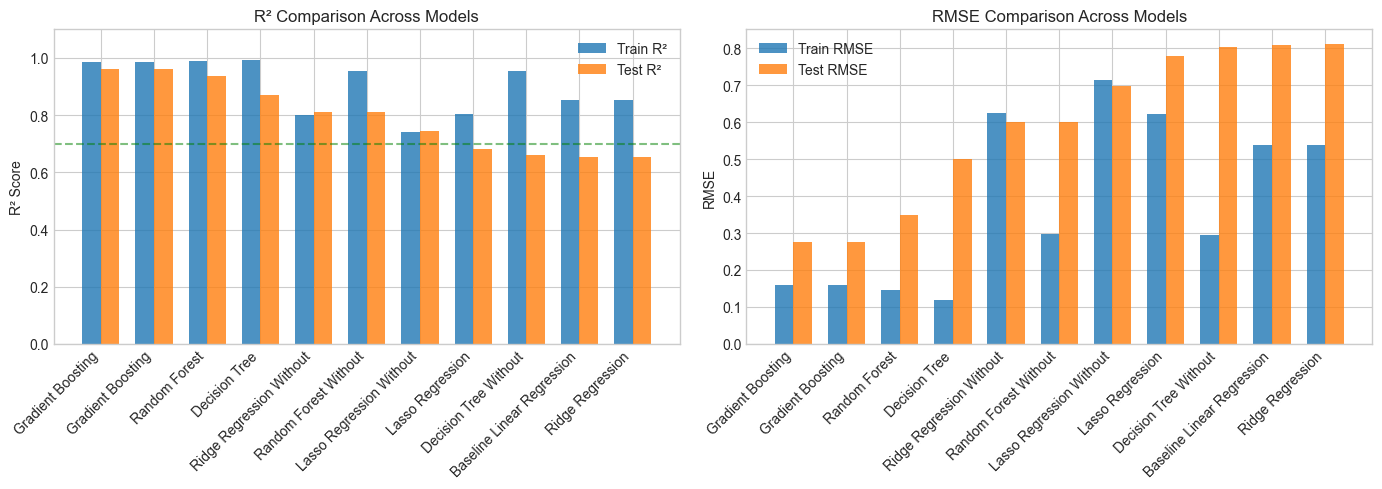

In [29]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Comparison
models = results_df['Model']
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, results_df['Train R2'], width, label='Train R²', alpha=0.8)
axes[0].bar(x + width/2, results_df['Test R2'], width, label='Test R²', alpha=0.8)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Comparison Across Models')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='Good threshold')

# RMSE Comparison
axes[1].bar(x - width/2, results_df['Train RMSE'], width, label='Train RMSE', alpha=0.8)
axes[1].bar(x + width/2, results_df['Test RMSE'], width, label='Test RMSE', alpha=0.8)
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE Comparison Across Models')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

### Model Iteration Reflection

*Before selecting your best model, reflect on what you learned:*

**Questions to answer:**
- Which model improved most over the baseline?
- Did any models show signs of overfitting (big train vs test gap)?
- Did regularization (Ridge/Lasso) help or hurt performance?
- Did tree-based models (Decision Tree, Random Forest) work better than linear models?

**Your reflection:**

The baseline model gave us an R2 Train score of 0.8538 and test score of 0.6553 meaning that the model was overfitting on the training data. Once the baseline was shwon the testing data it did not perform too well. The most intriguing was the Ridge Regression model which had a higher R2 score on the testing set of data than the training set of data which is a sign of underfitting or a "too simple' model. Comparing the performance of the models when trained with PE/PS ratio all of the models R2 performance dropped except both Lasso & Ridge. I think thhis can be explained because of the way that both Lasso and Ridge penalize features and their importance when training a model. "Decision Tree Without", "Ridge Regression Without", "Random Forest Without", "Decision Tree" all showed signes of overfitting with a reasonably higher R2 score on the training sets than the testing sets.

I believe that the model with the most improved performance over the baseline model is the Gradient Boosting Model, Tree based models seemed to workk better than linear models in my case because they are better able to capture the non-linearity and complexity of the stock market data set.

In [246]:
print(f'{results_df}')

                         Model  Train R2  Test R2  Train RMSE  Test RMSE  \
9            Gradient Boosting    0.9871   0.9598      0.1595     0.2766   
10           Gradient Boosting    0.9871   0.9598      0.1595     0.2766   
7                Random Forest    0.9892   0.9362      0.1459     0.3483   
5                Decision Tree    0.9927   0.8689      0.1198     0.4991   
2     Ridge Regression Without    0.8017   0.8106      0.6259     0.5999   
8        Random Forest Without    0.9549   0.8104      0.2985     0.6003   
4     Lasso Regression Without    0.7426   0.7441      0.7132     0.6975   
3             Lasso Regression    0.8043   0.6813      0.6219     0.7783   
6        Decision Tree Without    0.9559   0.6599      0.2953     0.8040   
0   Baseline Linear Regression    0.8538   0.6553      0.5376     0.8094   
1             Ridge Regression    0.8536   0.6545      0.5378     0.8104   

    Train MAE  Test MAE  
9      0.1168    0.1940  
10     0.1168    0.1940  
7      0.

## Section 9: Feature Importance & Selection

**Important:** Your final model should use only **4-8 features**. This section helps you identify which features matter most.

Feature Importance (Random Forest):
                     Feature  Importance
1                   earnings    0.623085
6                 net-assets    0.108045
8                   ps-ratio    0.089515
0                    revenue    0.069074
7                   pe-ratio    0.052118
3               total-assets    0.026709
5                 total-debt    0.005093
9           return-on-assets    0.004581
2           operating-margin    0.003944
10          return-on-equity    0.003796
4          total-liabilities    0.003316
11            debt-to-equity    0.003094
18       Industry_Technology    0.001660
16      Industry_Real Estate    0.001542
23               Country_USA    0.001277
21             Country_Other    0.000698
14          Industry_Oil&Gas    0.000468
17           Industry_Retail    0.000466
19             Country_India    0.000455
15  Industry_Pharmaceuticals    0.000428
12             Industry_Food    0.000207
22                Country_UK    0.000181
13        Industry_In

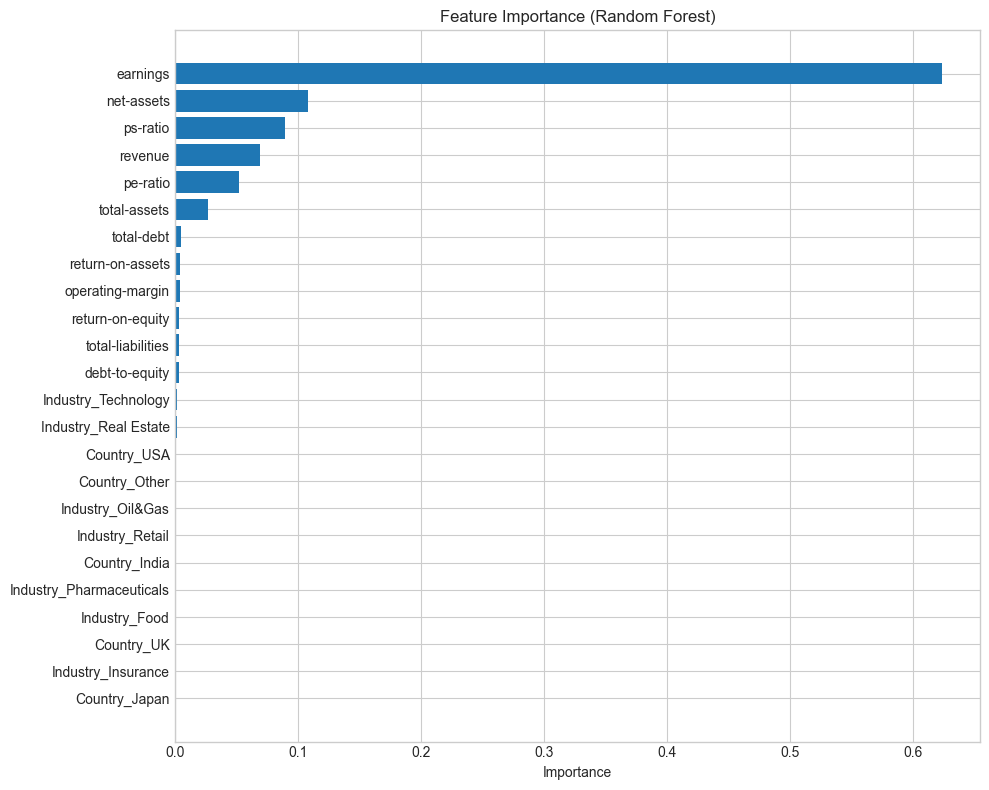

In [247]:
# Get feature importance from Random Forest (works well for this)
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_trained.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Random Forest):")
print(rf_importance)

# Visualize
plt.figure(figsize=(10, 8))
plt.barh(rf_importance['Feature'][::-1], rf_importance['Importance'][::-1])
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

In [248]:
# Also check correlations with target
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print("Absolute Correlations with Target:")
print(correlations)

Absolute Correlations with Target:
total-assets                0.756769
revenue                     0.756391
earnings                    0.751320
net-assets                  0.749712
total-liabilities           0.690329
total-debt                  0.678668
Industry_Technology         0.298271
ps-ratio                    0.212241
return-on-assets            0.146914
Industry_Food               0.129567
Industry_Real Estate        0.114971
Country_Other               0.113721
Country_USA                 0.112313
Industry_Retail             0.086522
Country_India               0.082217
Country_Japan               0.062585
debt-to-equity              0.059371
Industry_Pharmaceuticals    0.055921
pe-ratio                    0.042107
Country_UK                  0.033069
operating-margin            0.013501
Industry_Oil&Gas            0.010397
Industry_Insurance          0.005615
return-on-equity            0.002199
dtype: float64


In [249]:
# TODO: Select your top features (4-8 features)
#
# Based on the importance analysis above, choose your best features.
# Consider both Random Forest importance AND correlations.
# Also think about what makes sense from a domain perspective.

SELECTED_FEATURES = [
    'total-assets',
    'earnings',
    'total-debt',
    'return-on-assets',
    'return-on-equity',
    'debt-to-equity',
    'revenue',
    'net-assets',
    'Industry_Pharmaceuticals',
    'Industry_Technology',
    'Industry_Real Estate',
    'Industry_Food',
    'Industry_Oil&Gas',
    'Industry_Insurance',
    'Industry_Retail'
    ]

# Fallback if you haven't selected yet
if len(SELECTED_FEATURES) == 0:
    SELECTED_FEATURES = rf_importance['Feature'].head(6).tolist()
    print(f"Using top 6 features from Random Forest: {SELECTED_FEATURES}")
else:
    print(f"Selected features ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")

Selected features (15): ['total-assets', 'earnings', 'total-debt', 'return-on-assets', 'return-on-equity', 'debt-to-equity', 'revenue', 'net-assets', 'Industry_Pharmaceuticals', 'Industry_Technology', 'Industry_Real Estate', 'Industry_Food', 'Industry_Oil&Gas', 'Industry_Insurance', 'Industry_Retail']


In [250]:
# Retrain with selected features only
X_train_selected = X_train_scaled[SELECTED_FEATURES]
X_test_selected = X_test_scaled[SELECTED_FEATURES]

print(f"Training with {len(SELECTED_FEATURES)} selected features...")

# Test a few models with selected features
selected_results = []

for name, model in [('Linear Regression', LinearRegression()),
                    ('Ridge', Ridge(alpha=1.0)),
                    ('Random Forest', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))]:
    results, trained, _ = evaluate_model(model, X_train_selected, X_test_selected, y_train, y_test, name)
    selected_results.append(results)
    print(f"{name} with {len(SELECTED_FEATURES)} features - Test R²: {results['Test R2']:.4f}")

selected_df = pd.DataFrame(selected_results)

Training with 15 selected features...
Linear Regression with 15 features - Test R²: 0.7673
Ridge with 15 features - Test R²: 0.7672
Random Forest with 15 features - Test R²: 0.8004


### Feature Selection Justification

**Questions to answer:**
- Which features did you select and why?
- Did performance drop significantly with fewer features?
- Do these features make sense from a domain perspective?
- These are the features users will input in your Streamlit app—are they reasonable to ask for?

**Your justification:**

[Write your justification here]

## Section 10: Best Model Selection

In [263]:
# TODO: Choose and train your final model with selected features
#
# Based on your analysis, pick the best model type and instantiate it.
# Consider: performance, consistency, simplicity
#
# Example: final_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# YOUR CODE HERE:
# final_model = ...

final_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2, loss='squared_error', random_state=42)

In [264]:
# Fit and evaluate final model
final_model.fit(X_train_selected, y_train)
y_pred = final_model.predict(X_test_selected)

# Final metrics
final_r2 = r2_score(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_mae = mean_absolute_error(y_test, y_pred)

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)
print(f"Model: {type(final_model).__name__}")
print(f"Features: {SELECTED_FEATURES}")
print(f"\nTest R²: {final_r2:.4f}")
print(f"Test RMSE: {final_rmse:,.2f}")
print(f"Test MAE: {final_mae:,.2f}")
print(f"\nRMSE as % of target range: {final_rmse/target_range*100:.1f}%")

FINAL MODEL PERFORMANCE
Model: GradientBoostingRegressor
Features: ['total-assets', 'earnings', 'total-debt', 'return-on-assets', 'return-on-equity', 'debt-to-equity', 'revenue', 'net-assets', 'Industry_Pharmaceuticals', 'Industry_Technology', 'Industry_Real Estate', 'Industry_Food', 'Industry_Oil&Gas', 'Industry_Insurance', 'Industry_Retail']

Test R²: 0.8023
Test RMSE: 0.61
Test MAE: 0.46

RMSE as % of target range: 7.6%


### Best Model Justification

*Explain why you chose this model as your best:*

**Questions to consider:**
- Why did you select this model over others?
- Is there significant overfitting (train vs test gap)?
- How does the performance compare to your baseline?
- Would a simpler model be almost as good?
- Does the RMSE represent acceptable prediction error for your problem?

**Your justification:**

While choosing my final model it came close between GradientBoosting and RandomForest with RandomForest finalt R2 test score of 0.8004 and GradientBoosting got a final R2 score of 0.8023. Although they were very close i chose GradientBoost as my final model because i feel it best captures the non-lnear complexity of the stock market data, reduces noise, and had a slightly better accuracy.

Compared to the performance of all the models before removing the PE and PS ratios from the training i feel like the GradientBoost model still performed well on the marketcap prediction instead of memorizing the data. There are no signs of overfitting withthis model and the performance has well improved over the baseline model which seemed to be good at memorizing the median and giving aa "ball park" prediction. 

Stock Market data in itself is complex and hard to predict a companies true value due to so many different factors than just the fundamentals. Things like market sentiment, headlines, and other outside factors can affect the value of a company. Therefore, i believe a simple model would not be able to capture and make better predictions given the complexity of the stock market. 

## Section 11: Best Model Analysis

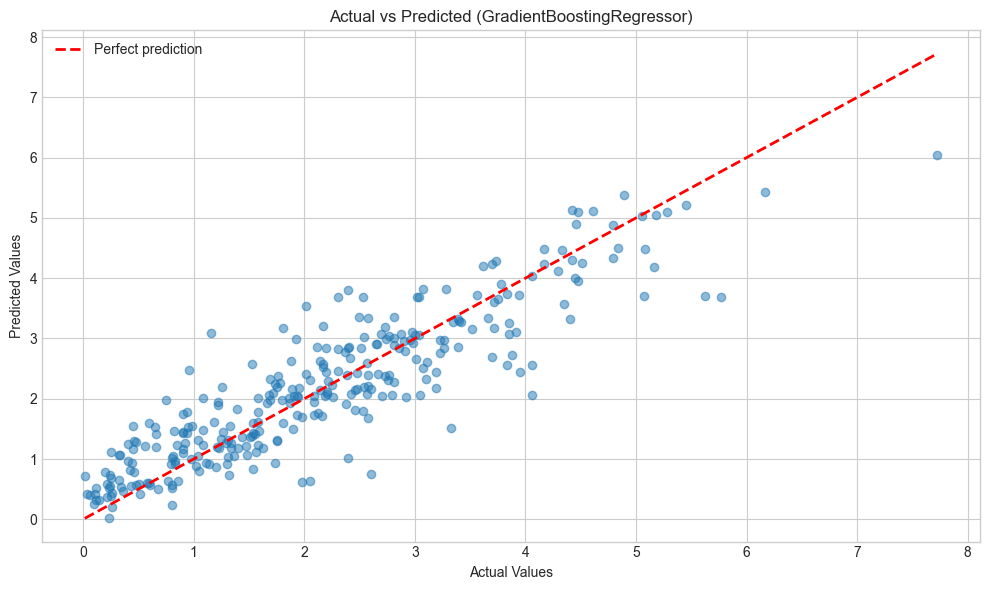

In [265]:
# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted ({type(final_model).__name__})')
plt.legend()
plt.tight_layout()
plt.show()

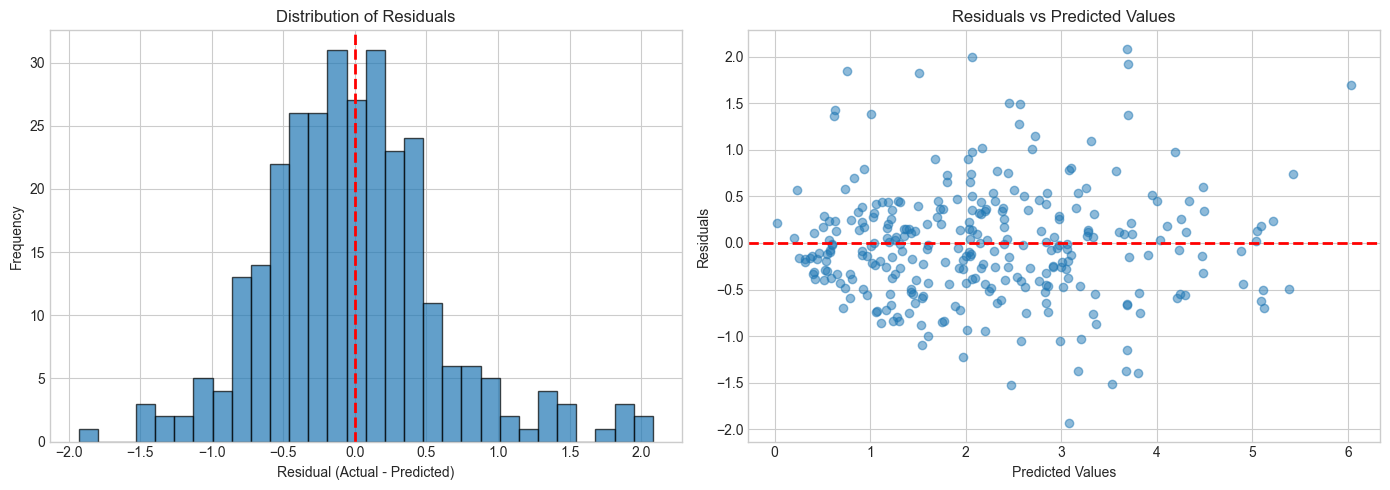

Residual mean (should be ~0): -0.02
Residual std: 0.61


In [266]:
# Residual analysis
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution (should be roughly normal, centered at 0)
axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Residuals')

# Residuals vs Predicted (should show no pattern)
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted Values')

plt.tight_layout()
plt.show()

print(f"Residual mean (should be ~0): {residuals.mean():.2f}")
print(f"Residual std: {residuals.std():,.2f}")

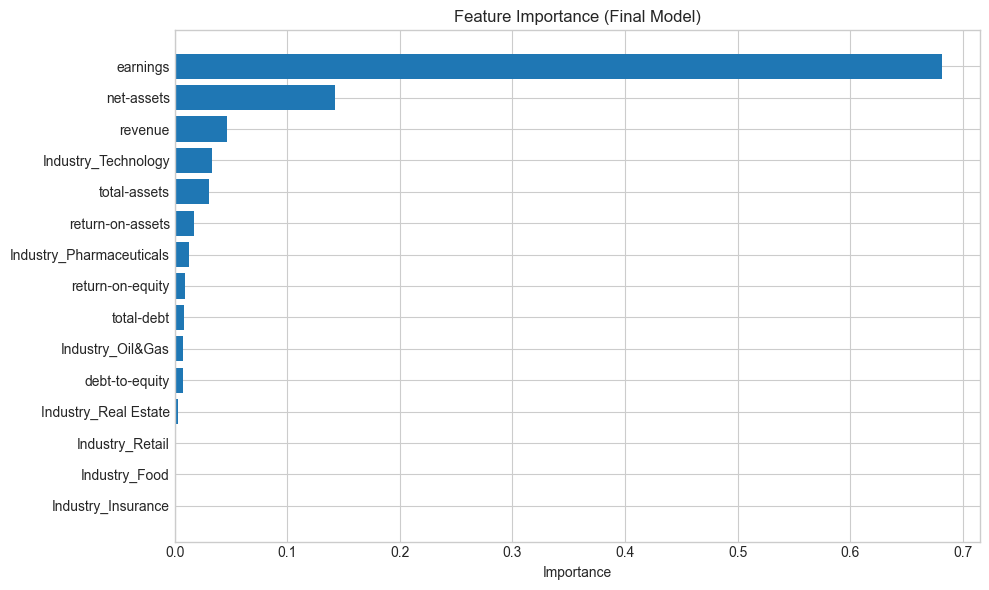

In [267]:
# Feature importance for final model (with selected features)
if hasattr(final_model, 'feature_importances_'):
    final_importance = pd.DataFrame({
        'Feature': SELECTED_FEATURES,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(final_importance['Feature'], final_importance['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance (Final Model)')
    plt.tight_layout()
    plt.show()
elif hasattr(final_model, 'coef_'):
    final_importance = pd.DataFrame({
        'Feature': SELECTED_FEATURES,
        'Coefficient': final_model.coef_
    }).sort_values('Coefficient', key=abs, ascending=True)
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if c > 0 else 'red' for c in final_importance['Coefficient']]
    plt.barh(final_importance['Feature'], final_importance['Coefficient'], color=colors)
    plt.xlabel('Coefficient')
    plt.title('Feature Coefficients (Final Model)')
    plt.tight_layout()
    plt.show()

## Section 12: Save Model and Artifacts

In [268]:
# Create a new scaler fitted only on selected features
final_scaler = StandardScaler()
X_train_final = X_train[SELECTED_FEATURES]
final_scaler.fit(X_train_final)

# Save the best model
model_path = '../models/regression_model.pkl'
joblib.dump(final_model, model_path)
print(f"Model saved to {model_path}")

# Save the scaler (fitted on selected features only)
scaler_path = '../models/regression_scaler.pkl'
joblib.dump(final_scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Save feature names (the selected features for Streamlit app)
features_path = '../models/regression_features.pkl'
joblib.dump(SELECTED_FEATURES, features_path)
print(f"Features saved to {features_path}")

Model saved to ../models/regression_model.pkl
Scaler saved to ../models/regression_scaler.pkl
Features saved to ../models/regression_features.pkl


In [269]:
# Verify saved model works
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_features = joblib.load(features_path)

# Test prediction
test_sample = X_test[loaded_features].iloc[[0]]
test_sample_scaled = loaded_scaler.transform(test_sample)
test_pred = loaded_model.predict(test_sample_scaled)

print(f"\nModel verification:")
print(f"Features used: {loaded_features}")
print(f"Sample input: {test_sample.values[0]}")
print(f"Predicted: {test_pred[0]:,.2f}")
print(f"Actual: {y_test.iloc[0]:,.2f}")
print(f"\nModel saved and verified successfully!")


Model verification:
Features used: ['total-assets', 'earnings', 'total-debt', 'return-on-assets', 'return-on-equity', 'debt-to-equity', 'revenue', 'net-assets', 'Industry_Pharmaceuticals', 'Industry_Technology', 'Industry_Real Estate', 'Industry_Food', 'Industry_Oil&Gas', 'Industry_Insurance', 'Industry_Retail']
Sample input: [ 1.16938136e+00 -5.88266316e-03  1.04380405e+00 -7.06316501e-06
 -3.85181501e-01  2.69460571e+01  3.29303747e-01  1.02473165e-02
  0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00]
Predicted: 0.51
Actual: 0.81

Model saved and verified successfully!


## Section 13: Binning Strategy for Classification

**IMPORTANT:** Before you start Notebook 03, you need to send your binning strategy to Abishek on Slack for approval by **Feb 15**.

### Analyze Target Distribution

In [270]:
# Look at target distribution to help decide binning
print(f"Target: {TARGET}")
print(f"\nDescriptive Statistics:")
print(y.describe())

print(f"\nPercentiles:")
for p in [10, 25, 33, 50, 67, 75, 90]:
    print(f"{p}th percentile: {y.quantile(p/100):,.2f}")

Target: marketcap

Descriptive Statistics:
count    1490.000000
mean        2.124606
std         1.400941
min         0.000070
25%         1.025134
50%         1.916185
75%         2.987321
max         8.064636
Name: marketcap, dtype: float64

Percentiles:
10th percentile: 0.44
25th percentile: 1.03
33th percentile: 1.32
50th percentile: 1.92
67th percentile: 2.58
75th percentile: 2.99
90th percentile: 4.06


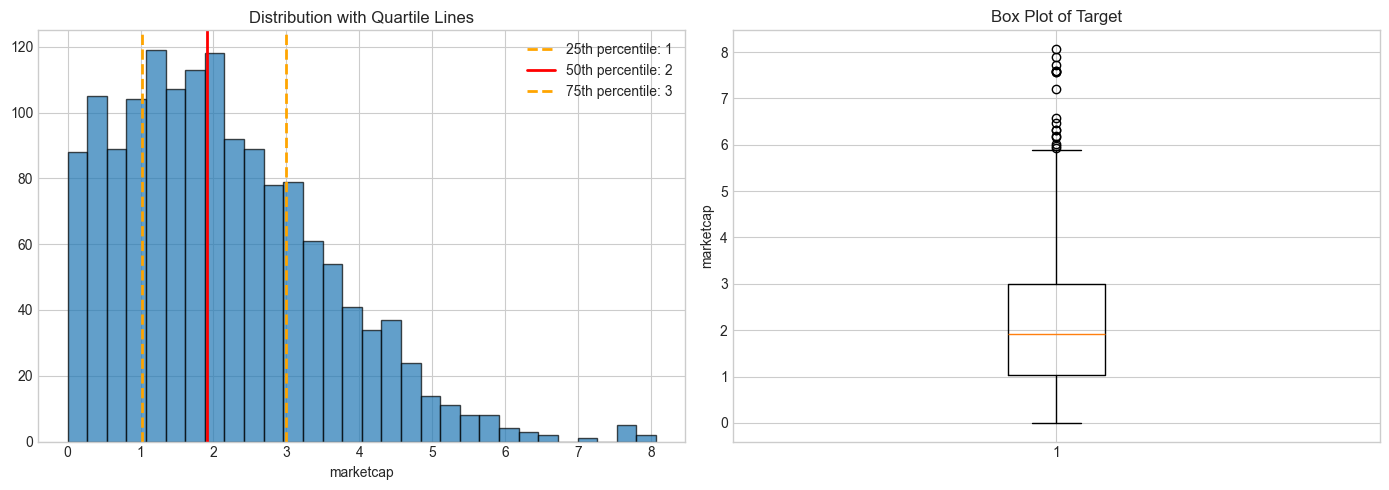

In [271]:
# Visualize potential binning strategies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with quartile lines
axes[0].hist(y, bins=30, edgecolor='black', alpha=0.7)
for p, color, style in [(25, 'orange', '--'), (50, 'red', '-'), (75, 'orange', '--')]:
    axes[0].axvline(y.quantile(p/100), color=color, linestyle=style, linewidth=2,
                     label=f'{p}th percentile: {y.quantile(p/100):,.0f}')
axes[0].set_xlabel(TARGET)
axes[0].set_title('Distribution with Quartile Lines')
axes[0].legend()

# Box plot
axes[1].boxplot(y)
axes[1].set_ylabel(TARGET)
axes[1].set_title('Box Plot of Target')

plt.tight_layout()
plt.show()

### Proposed Binning Strategy

*Complete this section and send to Abishek on Slack by Feb 15:*

**1. How many categories will you create?**

I will create 5 Categories:
- Micro Cap
- Small Cap
- Mid Cap
- Large Cap
- Mega Cap

**2. What are your bin thresholds?**

- Micro Cap: < $250 Million
- Small Cap: $250 Million - $2Billion
- Mid Cap: $2 Billion - $10 Billion
- Large Cap: $10 Billion - $200 Billion
- Mega Cap: $200 Billion +

**3. Why does this binning make sense for your problem?**

- In the market $250 Million and less is considered micro cap/start up size companies with high volitility and risk. 
- Small Cap are still younger companies but have higher reward potential and range from $250Million to $2Billion.
- Mid Caps range from $2Billion to $10Billion and are your more stable companies still with growth potential.
- Large Cap companies are those ranging from $10Billion to $200Billion, these are your S&P and Nasdaq type companies.
- Mega Cap are $200 Billion plus, these are the Nvidia, AMD, and Amazon type companies.

In [272]:
# Preview your binning
def create_bins_preview(y, strategy='quartile'):
    if strategy == 'quartile':
        bins = [y.min()-1, y.quantile(0.25), y.quantile(0.75), y.max()+1]
        labels = ['Low', 'Medium', 'High']
    elif strategy == 'tertile':
        bins = [y.min()-1, y.quantile(0.33), y.quantile(0.67), y.max()+1]
        labels = ['Low', 'Medium', 'High']
    # Add your custom strategy here if needed
    
    return pd.cut(y, bins=bins, labels=labels)

# Preview with quartile binning
y_binned = create_bins_preview(y, 'quartile')
print("Preview of binned target (using quartiles):")
print(y_binned.value_counts().sort_index())
print(f"\nPercentages:")
print((y_binned.value_counts(normalize=True) * 100).round(1).sort_index())

Preview of binned target (using quartiles):
marketcap
Low       373
Medium    744
High      373
Name: count, dtype: int64

Percentages:
marketcap
Low       25.0
Medium    49.9
High      25.0
Name: proportion, dtype: float64


---

## Summary

### What You Accomplished
- [ ] Loaded and prepared cleaned data
- [ ] Split data into train and test sets
- [ ] Scaled features appropriately
- [ ] Built a baseline model
- [ ] Tried multiple model types
- [ ] Performed cross-validation
- [ ] Selected top 4-8 features
- [ ] Compared and selected best model
- [ ] Analyzed model performance (residuals, feature importance)
- [ ] Saved model, scaler, and feature list
- [ ] Planned binning strategy for classification

### Key Results

**Best Model:** Gradient Boosting Regressor

**Selected Features:** 
Features used: 
- total-assets 
- earnings 
- total-debt 
- return-on-assets 
- return-on-equity 
- debt-to-equity
- revenue
- net-assets 
- Industry(One-Hot-Encoded)

**Test R²:**  0.8023
- Test RMSE: 0.61
- Test MAE: 0.46
- RMSE as % of target range: 7.6%


**Improvement over baseline:**  22% improvement over baseline

---

---

## Checkpoint 3 Submission Instructions

**Congratulations!** You've completed Checkpoint 3 (Regression Model).

### Step 1: Save This Notebook
- File -> Save (or Ctrl+S / Cmd+S)

### Step 2: Send Binning Strategy to Abishek
- Message Abishek on Slack with your binning strategy
- Include: number of categories, thresholds, and justification

### Step 3: Commit to GitHub

```bash
# Stage your changes
git add notebooks/02_regression_model.ipynb
git add models/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 3: Regression model with feature selection"

# Push to GitHub
git push
```

### Step 4: Submit to Canvas
1. Go to the Checkpoint 3 assignment on Canvas
2. Submit the link to your GitHub repository

---

## Next Steps

1. **Wait for binning approval** from Abishek
2. Move on to **Notebook 03: Classification Model**

---